# Week 9 V3: End-to-End Learned Query Pooler Evaluation

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/aniJani/reposynth/blob/Research/research/Week9_V3_Learned_Query_Integration.ipynb)

**Requirements:** Google Colab Pro with A100 GPU

## Overview

This notebook provides **end-to-end evaluation** comparing:
- `cce_heuristic`: CCE spike detection + keyword-based file matching (V2 baseline)
- `cce_learned`: CCE spike detection + **Learned Query Pooler** for file matching

## Pipeline

1. Clone real codebase (httpx)
2. Load CodeLlama-7b with 4-bit quantization
3. Generate/upload training data for learned model
4. Train Learned Query Pooler on codebase
5. Run end-to-end generation with both methods
6. Compare results

## 1. Setup & Installation

In [1]:
# Check GPU
!nvidia-smi

Thu Jan 29 00:12:35 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   34C    P0             44W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
# Install dependencies
!pip install -q torch transformers accelerate bitsandbytes sentence-transformers scipy scikit-learn pandas matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 45.5 MB/s eta 0:00:00


In [3]:
import os
import sys
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import re
import time
import random
from dataclasses import dataclass, field
from typing import List, Dict, Tuple, Any, Optional
from sentence_transformers import SentenceTransformer
from scipy.stats import entropy as scipy_entropy
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

# Colab check
try:
    from google.colab import files
    IN_COLAB = True
    print("Running in Google Colab")
except ImportError:
    IN_COLAB = False
    print("Running locally")

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

Running in Google Colab
Device: cuda
GPU: NVIDIA A100-SXM4-40GB
Memory: 42.5 GB


## 2. Clone Codebase (httpx)

In [4]:
# Clone httpx repository
REPO_URL = 'https://github.com/encode/httpx.git'
REPO_DIR = '/content/httpx'

if not os.path.exists(REPO_DIR):
    !git clone --depth 1 {REPO_URL} {REPO_DIR}
    print("Cloned httpx repository")
else:
    print("httpx already exists")

!ls {REPO_DIR}

Cloning into '/content/httpx'...
remote: Enumerating objects: 140, done.
remote: Counting objects: 100% (140/140), done.
remote: Compressing objects: 100% (133/133), done.
remote: Total 140 (delta 2), reused 47 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (140/140), 2.21 MiB | 16.66 MiB/s, done.
Resolving deltas: 100% (2/2), done.
Cloned httpx repository
CHANGELOG.md  httpx	  mkdocs.yml	  README.md	    scripts
docs	      LICENSE.md  pyproject.toml  requirements.txt  tests


In [5]:
# Load Python files from codebase
def load_codebase(repo_dir: str, src_folder: str = 'httpx') -> Dict[str, str]:
    """Load all Python files from the codebase."""
    documents = {}
    src_path = os.path.join(repo_dir, src_folder)

    for root, dirs, files_list in os.walk(src_path):
        # Skip test directories
        dirs[:] = [d for d in dirs if 'test' not in d.lower()]

        for file in files_list:
            if file.endswith('.py') and not file.startswith('test_'):
                filepath = os.path.join(root, file)
                rel_path = os.path.relpath(filepath, repo_dir)
                try:
                    with open(filepath, 'r', encoding='utf-8', errors='ignore') as f:
                        content = f.read()
                    if len(content) > 100:  # Skip tiny files
                        documents[rel_path] = content
                except Exception as e:
                    print(f"Error reading {rel_path}: {e}")

    return documents

CODEBASE = load_codebase(REPO_DIR)
FILE_LIST = list(CODEBASE.keys())
FILE_TO_IDX = {f: i for i, f in enumerate(FILE_LIST)}

print(f"Loaded {len(CODEBASE)} files")
print(f"Files: {FILE_LIST[:10]}...")

Loaded 23 files
Files: ['httpx/_client.py', 'httpx/_config.py', 'httpx/_decoders.py', 'httpx/__init__.py', 'httpx/_utils.py', 'httpx/_types.py', 'httpx/__version__.py', 'httpx/_auth.py', 'httpx/_urlparse.py', 'httpx/_api.py']...


## 3. Define Benchmark Examples

In [6]:
@dataclass
class BenchmarkExample:
    """Benchmark example for evaluation."""
    id: str
    query: str
    ground_truth_files: List[str]
    ground_truth_answer: str
    keywords: List[str] = field(default_factory=list)

# Define benchmark for httpx
BENCHMARK = [
    BenchmarkExample(
        id="httpx_001",
        query="How do I make a simple GET request with httpx?",
        ground_truth_files=["httpx/_api.py", "httpx/_client.py"],
        ground_truth_answer="Use httpx.get(url) for synchronous requests or async with httpx.AsyncClient().",
        keywords=["get", "request", "client"]
    ),
    BenchmarkExample(
        id="httpx_002",
        query="How do I send POST data with httpx?",
        ground_truth_files=["httpx/_api.py", "httpx/_client.py"],
        ground_truth_answer="Use httpx.post(url, data=dict) or json=dict for JSON data.",
        keywords=["post", "data", "json"]
    ),
    BenchmarkExample(
        id="httpx_003",
        query="How do I use httpx with async/await?",
        ground_truth_files=["httpx/_client.py"],
        ground_truth_answer="Use async with httpx.AsyncClient() as client: response = await client.get(url).",
        keywords=["async", "await", "AsyncClient"]
    ),
    BenchmarkExample(
        id="httpx_004",
        query="How do I set custom headers in httpx?",
        ground_truth_files=["httpx/_client.py", "httpx/_models.py"],
        ground_truth_answer="Pass headers={'key': 'value'} to request methods or client constructor.",
        keywords=["headers", "Headers"]
    ),
    BenchmarkExample(
        id="httpx_005",
        query="How do I handle timeouts in httpx?",
        ground_truth_files=["httpx/_config.py", "httpx/_client.py"],
        ground_truth_answer="Use timeout parameter: httpx.get(url, timeout=10.0) or Timeout object.",
        keywords=["timeout", "Timeout"]
    ),
    BenchmarkExample(
        id="httpx_006",
        query="How does httpx handle cookies?",
        ground_truth_files=["httpx/_client.py", "httpx/_models.py"],
        ground_truth_answer="Cookies persist in Client sessions. Use cookies parameter or client.cookies.",
        keywords=["cookies", "Cookies"]
    ),
    BenchmarkExample(
        id="httpx_007",
        query="How do I handle authentication in httpx?",
        ground_truth_files=["httpx/_auth.py", "httpx/_client.py"],
        ground_truth_answer="Use auth parameter with tuple (user, pass) or Auth class for custom auth.",
        keywords=["auth", "authentication", "BasicAuth"]
    ),
    BenchmarkExample(
        id="httpx_008",
        query="How does httpx handle redirects?",
        ground_truth_files=["httpx/_client.py"],
        ground_truth_answer="Redirects are followed by default. Use follow_redirects=False to disable.",
        keywords=["redirect", "follow_redirects"]
    ),
    BenchmarkExample(
        id="httpx_009",
        query="How do I upload files with httpx?",
        ground_truth_files=["httpx/_content.py", "httpx/_client.py"],
        ground_truth_answer="Use files parameter: httpx.post(url, files={'file': open('file.txt', 'rb')}).",
        keywords=["files", "upload", "multipart"]
    ),
    BenchmarkExample(
        id="httpx_010",
        query="How does httpx handle HTTP/2?",
        ground_truth_files=["httpx/_transports/default.py", "httpx/_client.py"],
        ground_truth_answer="Enable HTTP/2 with http2=True in Client constructor.",
        keywords=["http2", "HTTP/2"]
    ),
]

# Filter to only include files that exist in our codebase
for ex in BENCHMARK:
    ex.ground_truth_files = [f for f in ex.ground_truth_files if f in FILE_TO_IDX]

print(f"Benchmark: {len(BENCHMARK)} examples")
for ex in BENCHMARK[:3]:
    print(f"  {ex.id}: {ex.ground_truth_files}")

Benchmark: 10 examples
  httpx_001: ['httpx/_api.py', 'httpx/_client.py']
  httpx_002: ['httpx/_api.py', 'httpx/_client.py']
  httpx_003: ['httpx/_client.py']


## 4. Generate Training Data for Learned Model

In [7]:
def generate_training_samples(codebase: Dict[str, str], num_samples: int = 200) -> List[Dict]:
    """
    Generate synthetic training samples from codebase.
    Each sample has confused tokens and relevant files.
    """
    samples = []
    file_list = list(codebase.keys())

    # Extract keywords from each file
    file_keywords = {}
    for filepath, content in codebase.items():
        # Extract function/class names and important identifiers
        keywords = set()

        # Function names
        for match in re.finditer(r'def\s+(\w+)', content):
            keywords.add(match.group(1))

        # Class names
        for match in re.finditer(r'class\s+(\w+)', content):
            keywords.add(match.group(1))

        # Important identifiers (CamelCase or UPPER_CASE)
        for match in re.finditer(r'\b([A-Z][a-z]+[A-Z]\w*|[A-Z]{2,}\w*)\b', content):
            keywords.add(match.group(1))

        # File path parts
        parts = re.split(r'[/\\_.]', filepath.lower())
        keywords.update(p for p in parts if len(p) >= 3)

        file_keywords[filepath] = list(keywords)[:20]  # Limit

    # Generate samples
    for i in range(num_samples):
        # Pick 1-2 random files as ground truth
        num_files = random.randint(1, 2)
        selected_files = random.sample(file_list, min(num_files, len(file_list)))

        # Collect keywords from selected files
        all_keywords = []
        for f in selected_files:
            all_keywords.extend(file_keywords.get(f, []))

        if not all_keywords:
            continue

        # Sample confused tokens (mix of relevant + noise)
        relevant_tokens = random.sample(all_keywords, min(3, len(all_keywords)))

        # Add some noise tokens
        noise_tokens = random.sample(['the', 'is', 'to', 'and', 'for', 'in', 'of'], 2)

        confused_tokens = relevant_tokens + noise_tokens
        random.shuffle(confused_tokens)

        # Generate fake probabilities
        probs = np.random.dirichlet(np.ones(len(confused_tokens))).tolist()

        # Create query based on file content
        query_templates = [
            f"How does {relevant_tokens[0] if relevant_tokens else 'this'} work?",
            f"Where is {relevant_tokens[0] if relevant_tokens else 'the function'} defined?",
            f"What handles {relevant_tokens[0] if relevant_tokens else 'this feature'}?",
        ]
        query = random.choice(query_templates)

        samples.append({
            'sample_id': f'gen_{i:04d}',
            'confused_tokens': confused_tokens[:5],
            'confused_probs': probs[:5],
            'original_query': query,
            'generated_context': f"Looking for {' '.join(relevant_tokens[:2])}...",
            'relevant_files': selected_files,
        })

    return samples

print("Training data generator defined")

Training data generator defined


In [8]:
# Generate training data
print("Generating training data from httpx codebase...")
TRAINING_DATA = generate_training_samples(CODEBASE, num_samples=300)

# Split train/test
random.shuffle(TRAINING_DATA)
split_idx = int(len(TRAINING_DATA) * 0.85)
TRAIN_SAMPLES = TRAINING_DATA[:split_idx]
TEST_SAMPLES = TRAINING_DATA[split_idx:]

print(f"Generated {len(TRAINING_DATA)} samples")
print(f"Train: {len(TRAIN_SAMPLES)}, Test: {len(TEST_SAMPLES)}")

# Show example
if TRAIN_SAMPLES:
    print(f"\nExample sample:")
    sample = TRAIN_SAMPLES[0]
    for k, v in sample.items():
        print(f"  {k}: {v}")

Generating training data from httpx codebase...
Generated 300 samples
Train: 255, Test: 45

Example sample:
  sample_id: gen_0046
  confused_tokens: ['AsyncByteStream', 'in', 'the', '__aiter__', 'StreamConsumed']
  confused_probs: [0.3922374308207076, 0.1729688782065252, 0.21301929665834093, 0.16798069937633806, 0.05379369493808835]
  original_query: Where is AsyncByteStream defined?
  generated_context: Looking for AsyncByteStream __aiter__...
  relevant_files: ['httpx/_content.py', 'httpx/_models.py']


## 5. Define Learned Query Pooler

In [9]:
class LearnedQueryPooler(nn.Module):
    """Cross-attention based query pooler for file matching."""

    def __init__(self, embed_dim=384, num_heads=4, dropout=0.1):
        super().__init__()
        self.embed_dim = embed_dim

        # Sentence encoder (frozen, only for getting embeddings)
        self.encoder = SentenceTransformer('all-MiniLM-L6-v2')

        # Learnable query vectors
        self.query_vectors = nn.Parameter(torch.randn(4, embed_dim) * 0.02)

        # Trainable projection layers
        self.input_proj = nn.Linear(embed_dim, embed_dim)
        self.file_proj = nn.Linear(embed_dim, embed_dim)

        # Cross-attention
        self.cross_attn = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout, batch_first=True)

        # Output layers
        self.fc = nn.Sequential(
            nn.Linear(embed_dim, embed_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim, embed_dim)
        )

        # File scorer
        self.scorer = nn.Bilinear(embed_dim, embed_dim, 1)

        # Norms
        self.norm = nn.LayerNorm(embed_dim)

        # Cache
        self._file_paths = []
        self._file_embs = None

    def set_files(self, file_paths: List[str]):
        """Cache file embeddings."""
        self._file_paths = file_paths
        texts = [' '.join(re.split(r'[/\\_.]', p)) for p in file_paths]
        with torch.no_grad():
            embs = self.encoder.encode(texts, convert_to_tensor=True)
        # Clone to escape inference mode
        self._file_embs = embs.clone().detach().to(device)

    def _encode_texts(self, texts: List[str]) -> torch.Tensor:
        """Encode texts and return a normal (non-inference) tensor."""
        with torch.no_grad():
            embs = self.encoder.encode(texts, convert_to_tensor=True)
        # CRITICAL: clone().detach() to escape inference mode
        return embs.clone().detach().to(device)

    def forward(self, tokens: List[str], query: str = "", context: str = "") -> torch.Tensor:
        """Returns file scores."""
        # Encode inputs
        texts = tokens[:8]
        if query:
            texts.append(query)
        if context:
            texts.append(context[:200])
        if not texts:
            texts = [""]

        # Get embeddings (escaped from inference mode)
        input_embs = self._encode_texts(texts)

        # Project through trainable layer
        input_embs = self.input_proj(input_embs)

        # Cross-attention
        queries = self.query_vectors.unsqueeze(0)  # [1, 4, 384]
        keys = input_embs.unsqueeze(0)  # [1, N, 384]
        attended, _ = self.cross_attn(queries, keys, keys)

        # Pool and project
        pooled = self.norm(attended.mean(dim=1))  # [1, 384]
        output = self.fc(pooled)  # [1, 384]

        # Score files
        file_embs = self.file_proj(self._file_embs)
        num_files = file_embs.shape[0]
        query_exp = output.expand(num_files, -1)  # [N, 384]
        scores = self.scorer(query_exp, file_embs).squeeze(-1)  # [N]

        return scores

    def predict(self, tokens: List[str], query: str = "", context: str = "", top_k: int = 3) -> List[str]:
        """Get top-k files."""
        with torch.no_grad():
            scores = self.forward(tokens, query, context)
            probs = F.softmax(scores, dim=-1)
            _, indices = torch.topk(probs, min(top_k, len(self._file_paths)))
            return [self._file_paths[i] for i in indices.tolist()]

print("LearnedQueryPooler defined (fixed inference mode issue)")

LearnedQueryPooler defined (fixed inference mode issue)


## 6. Train Learned Query Pooler

In [10]:
# Initialize model
learned_model = LearnedQueryPooler(embed_dim=384, num_heads=4, dropout=0.1).to(device)
learned_model.set_files(FILE_LIST)

trainable_params = sum(p.numel() for p in learned_model.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable_params:,}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Trainable parameters: 24,045,697


TRAINING LEARNED QUERY POOLER
Epoch  1/25: Loss=0.1202 (255 samples)
Epoch  5/25: Loss=0.0658 (255 samples)
Epoch 10/25: Loss=0.0340 (255 samples)
Epoch 15/25: Loss=0.0158 (255 samples)
Epoch 20/25: Loss=0.0071 (255 samples)
Epoch 25/25: Loss=0.0044 (255 samples)


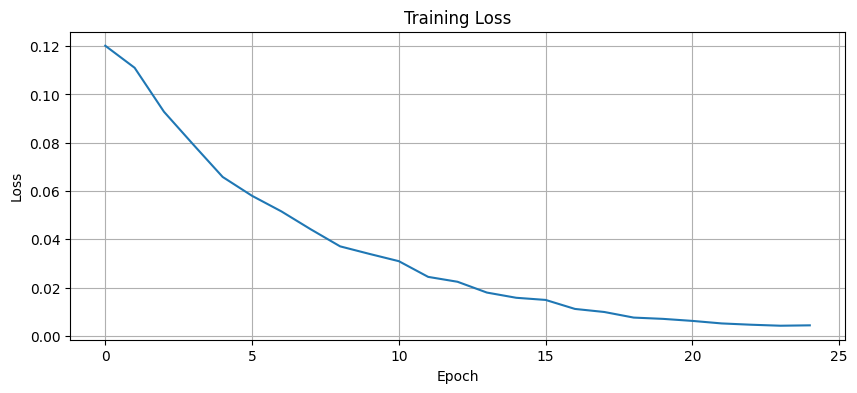

In [11]:
def train_model(model, train_samples, file_to_idx, epochs=25, lr=2e-4):
    """Train the learned query pooler."""
    model.train()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    losses = []

    for epoch in range(epochs):
        epoch_loss = 0
        epoch_count = 0
        random.shuffle(train_samples)

        for sample in train_samples:
            tokens = sample.get('confused_tokens', [])
            query = sample.get('original_query', '')
            context = sample.get('generated_context', '')
            relevant = sample.get('relevant_files', [])

            if not tokens:
                continue

            # Create target
            target = torch.zeros(len(file_to_idx), device=device)
            valid = 0
            for f in relevant:
                if f in file_to_idx:
                    target[file_to_idx[f]] = 1.0
                    valid += 1

            if valid == 0:
                continue

            target = target / target.sum()

            # Forward
            optimizer.zero_grad()
            scores = model(tokens, query, context)

            # Loss
            log_probs = F.log_softmax(scores, dim=-1)
            loss = F.kl_div(log_probs, target, reduction='batchmean')

            # Backward
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            epoch_loss += loss.item()
            epoch_count += 1

        scheduler.step()
        avg_loss = epoch_loss / max(epoch_count, 1)
        losses.append(avg_loss)

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:2d}/{epochs}: Loss={avg_loss:.4f} ({epoch_count} samples)")

    return losses

# Train
print("=" * 60)
print("TRAINING LEARNED QUERY POOLER")
print("=" * 60)

losses = train_model(learned_model, TRAIN_SAMPLES, FILE_TO_IDX, epochs=25, lr=2e-4)

plt.figure(figsize=(10, 4))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.grid(True)
plt.show()

## 7. Define Embedding Retriever

In [12]:
class EmbeddingRetriever:
    """Semantic retriever using sentence embeddings."""

    def __init__(self, documents: Dict[str, str]):
        self.documents = documents
        self.doc_names = list(documents.keys())
        self.encoder = SentenceTransformer('all-MiniLM-L6-v2')

        # Embed documents (first 1000 chars)
        print("Embedding documents...")
        doc_texts = [f"{name}: {content[:1000]}" for name, content in documents.items()]
        self.doc_embs = self.encoder.encode(doc_texts, show_progress_bar=True)
        print(f"Embedded {len(self.doc_names)} documents")

    def retrieve(self, query: str, top_k: int = 3) -> List[Dict]:
        """Retrieve top-k documents."""
        query_emb = self.encoder.encode([query])[0]

        # Cosine similarity
        scores = np.dot(self.doc_embs, query_emb) / (
            np.linalg.norm(self.doc_embs, axis=1) * np.linalg.norm(query_emb) + 1e-8
        )

        top_indices = np.argsort(scores)[::-1][:top_k]
        results = []
        for i in top_indices:
            results.append({
                'source': self.doc_names[i],
                'score': float(scores[i]),
                'content': self.documents[self.doc_names[i]][:500]
            })
        return results

# Create retriever
retriever = EmbeddingRetriever(CODEBASE)

Embedding documents...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Embedded 23 documents


## 8. Define Heuristic Matcher

In [13]:
class HeuristicMatcher:
    """Keyword-based file matching (baseline)."""

    def __init__(self, file_paths: List[str]):
        self.file_paths = file_paths
        self.file_kw = {}
        for path in file_paths:
            parts = re.split(r'[/\\_.]', path.lower())
            self.file_kw[path] = set(p for p in parts if len(p) >= 2)

    def match(self, tokens: List[str], query: str = "", top_k: int = 3) -> List[str]:
        keywords = set(t.lower() for t in tokens)
        keywords.update(w.lower() for w in re.findall(r'\w+', query) if len(w) >= 2)

        scores = {}
        for path, kw in self.file_kw.items():
            scores[path] = len(keywords & kw)

        sorted_files = sorted(scores.items(), key=lambda x: -x[1])
        return [f for f, _ in sorted_files[:top_k]]

heuristic_matcher = HeuristicMatcher(FILE_LIST)
print("HeuristicMatcher defined")

HeuristicMatcher defined


## 9. Load CodeLlama-7b

In [14]:
# Load CodeLlama with 4-bit quantization
MODEL_NAME = "codellama/CodeLlama-7b-Instruct-hf"

print(f"Loading {MODEL_NAME}...")

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
llm = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print("Model loaded!")

Loading codellama/CodeLlama-7b-Instruct-hf...


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/411 [00:00<?, ?B/s]

...

model-00001-of-00002.safetensors:   0%|          | 0.00/9.98G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/3.50G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

Model loaded!


## 10. Define CCE Spike Detection

In [15]:
class CCESpikeDetector:
    """Detect entropy spikes during generation."""

    def __init__(self, tokenizer, threshold: float = 3.0, cooldown: int = 15):
        self.tokenizer = tokenizer
        self.threshold = threshold
        self.cooldown = cooldown
        self.last_spike = -cooldown

        # Build code token indices
        self.code_indices = []
        vocab_size = min(tokenizer.vocab_size, 32000)
        for idx in range(vocab_size):
            try:
                token = tokenizer.decode([idx])
                if re.search(r'[_A-Z]{2,}|\(|\)|\{|\}|def|class|import|return', token):
                    self.code_indices.append(idx)
            except:
                pass
        self.code_indices = torch.tensor(self.code_indices, device=device)

    def compute_cce(self, logits: torch.Tensor) -> float:
        """Compute code-conditional entropy."""
        probs = F.softmax(logits, dim=-1)
        if len(self.code_indices) > 0:
            code_probs = probs[self.code_indices].cpu().numpy()
            code_probs = code_probs / (code_probs.sum() + 1e-10)
            return float(scipy_entropy(code_probs + 1e-10, base=2))
        return 0.0

    def check_spike(self, logits: torch.Tensor, position: int) -> Tuple[bool, float]:
        """Check if current position is a spike."""
        cce = self.compute_cce(logits)
        is_spike = cce > self.threshold and (position - self.last_spike) >= self.cooldown
        if is_spike:
            self.last_spike = position
        return is_spike, cce

    def get_confused_tokens(self, logits: torch.Tensor, top_k: int = 5) -> Tuple[List[str], List[float]]:
        """Get top confused tokens."""
        probs = F.softmax(logits, dim=-1)
        top_probs, top_indices = torch.topk(probs, top_k)

        tokens = []
        token_probs = []
        for idx, prob in zip(top_indices.tolist(), top_probs.tolist()):
            token = self.tokenizer.decode([idx]).strip()
            if len(token) >= 2:
                tokens.append(token)
                token_probs.append(prob)

        return tokens, token_probs

    def reset(self):
        self.last_spike = -self.cooldown

spike_detector = CCESpikeDetector(tokenizer, threshold=3.0, cooldown=15)
print(f"CCESpikeDetector initialized with {len(spike_detector.code_indices)} code tokens")

CCESpikeDetector initialized with 1634 code tokens


## 11. Define Generation Functions

In [16]:
@dataclass
class GenerationResult:
    """Result of generation."""
    answer: str
    retrieved_files: List[str]
    num_spikes: int
    tokens_used: int
    generation_time: float


def generate_with_cce(
    query: str,
    matcher,  # Either learned_model or heuristic_matcher
    use_learned: bool,
    max_tokens: int = 100,
    max_retrievals: int = 3,
) -> GenerationResult:
    """Generate with CCE-triggered retrieval."""
    start_time = time.time()
    spike_detector.reset()

    prompt = f"Question: {query}\nAnswer:"
    input_ids = tokenizer.encode(prompt, return_tensors='pt').to(device)

    retrieved_files = []
    num_spikes = 0
    generated_text = ""

    for step in range(max_tokens):
        with torch.no_grad():
            outputs = llm(input_ids)
            logits = outputs.logits[:, -1, :]

        # Check for spike
        is_spike, cce = spike_detector.check_spike(logits[0], step)

        if is_spike and num_spikes < max_retrievals:
            # Get confused tokens
            tokens, probs = spike_detector.get_confused_tokens(logits[0])

            # Get files based on method
            if use_learned:
                files = matcher.predict(tokens, query, generated_text, top_k=2)
            else:
                files = matcher.match(tokens, query, top_k=2)

            retrieved_files.extend(files)
            num_spikes += 1

            # Inject context
            if files:
                context_text = ""
                for f in files[:1]:  # Use first file
                    if f in CODEBASE:
                        context_text = f"\n[From {f}]:\n{CODEBASE[f][:300]}\n"
                        break

                if context_text:
                    context_ids = tokenizer.encode(context_text, return_tensors='pt').to(device)
                    input_ids = torch.cat([input_ids, context_ids], dim=-1)

        # Sample next token
        probs = F.softmax(logits, dim=-1)
        next_token = torch.multinomial(probs, num_samples=1)
        input_ids = torch.cat([input_ids, next_token], dim=-1)
        generated_text += tokenizer.decode(next_token[0])

        # Stop on EOS
        if next_token.item() == tokenizer.eos_token_id:
            break

    # Decode final answer
    full_output = tokenizer.decode(input_ids[0], skip_special_tokens=True)
    answer = full_output.split("Answer:")[-1].strip()[:500]

    return GenerationResult(
        answer=answer,
        retrieved_files=list(set(retrieved_files)),
        num_spikes=num_spikes,
        tokens_used=input_ids.shape[1],
        generation_time=time.time() - start_time
    )


def generate_no_retrieval(query: str, max_tokens: int = 100) -> GenerationResult:
    """Generate without any retrieval (baseline)."""
    start_time = time.time()

    prompt = f"Question: {query}\nAnswer:"
    input_ids = tokenizer.encode(prompt, return_tensors='pt').to(device)

    with torch.no_grad():
        outputs = llm.generate(
            input_ids,
            max_new_tokens=max_tokens,
            do_sample=True,
            temperature=0.7,
            pad_token_id=tokenizer.pad_token_id,
        )

    answer = tokenizer.decode(outputs[0], skip_special_tokens=True)
    answer = answer.split("Answer:")[-1].strip()[:500]

    return GenerationResult(
        answer=answer,
        retrieved_files=[],
        num_spikes=0,
        tokens_used=outputs.shape[1],
        generation_time=time.time() - start_time
    )

print("Generation functions defined")

Generation functions defined


## 12. Define Evaluation Metrics

In [17]:
class Evaluator:
    """Evaluate generation quality."""

    def __init__(self):
        self.encoder = SentenceTransformer('all-MiniLM-L6-v2')

    def semantic_similarity(self, text1: str, text2: str) -> float:
        """Compute semantic similarity."""
        if not text1 or not text2:
            return 0.0
        embs = self.encoder.encode([text1, text2])
        sim = np.dot(embs[0], embs[1]) / (np.linalg.norm(embs[0]) * np.linalg.norm(embs[1]) + 1e-8)
        return float(max(0, sim))

    def retrieval_metrics(self, retrieved: List[str], ground_truth: List[str]) -> Dict:
        """Compute retrieval metrics."""
        if not retrieved or not ground_truth:
            return {'precision': 0, 'recall': 0, 'f1': 0}

        retrieved_set = set(retrieved)
        gt_set = set(ground_truth)
        hits = len(retrieved_set & gt_set)

        precision = hits / len(retrieved_set)
        recall = hits / len(gt_set)
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

        return {'precision': precision, 'recall': recall, 'f1': f1}

    def evaluate(self, result: GenerationResult, example: BenchmarkExample) -> Dict:
        """Full evaluation."""
        correctness = self.semantic_similarity(result.answer, example.ground_truth_answer)
        ret_metrics = self.retrieval_metrics(result.retrieved_files, example.ground_truth_files)

        # Composite score
        composite = 0.4 * correctness + 0.3 * ret_metrics['f1'] + 0.2 * (1 - max(0, 1 - correctness) * 0.5) + 0.1

        return {
            'correctness': correctness,
            'precision': ret_metrics['precision'],
            'recall': ret_metrics['recall'],
            'f1': ret_metrics['f1'],
            'composite': composite,
            'num_spikes': result.num_spikes,
            'tokens': result.tokens_used,
            'time': result.generation_time
        }

evaluator = Evaluator()
print("Evaluator defined")

Evaluator defined


## 13. Run End-to-End Experiment

In [18]:
learned_model.eval()

results = {
    'no_retrieval': [],
    'cce_heuristic': [],
    'cce_learned': []
}

print("=" * 70)
print("END-TO-END EXPERIMENT")
print("=" * 70)
print(f"Benchmark: {len(BENCHMARK)} examples")
print(f"Methods: no_retrieval, cce_heuristic, cce_learned")
print()

for i, example in enumerate(BENCHMARK):
    print(f"\n[{i+1}/{len(BENCHMARK)}] {example.query[:50]}...")
    print(f"  Ground truth: {example.ground_truth_files}")

    # No retrieval baseline
    try:
        nr_result = generate_no_retrieval(example.query)
        nr_eval = evaluator.evaluate(nr_result, example)
        results['no_retrieval'].append(nr_eval)
        print(f"  no_retrieval: correct={nr_eval['correctness']:.2f}")
    except Exception as e:
        print(f"  no_retrieval ERROR: {e}")

    # CCE Heuristic
    try:
        heur_result = generate_with_cce(example.query, heuristic_matcher, use_learned=False)
        heur_eval = evaluator.evaluate(heur_result, example)
        results['cce_heuristic'].append(heur_eval)
        print(f"  cce_heuristic: correct={heur_eval['correctness']:.2f}, F1={heur_eval['f1']:.2f}, files={heur_result.retrieved_files[:2]}")
    except Exception as e:
        print(f"  cce_heuristic ERROR: {e}")

    # CCE Learned
    try:
        learn_result = generate_with_cce(example.query, learned_model, use_learned=True)
        learn_eval = evaluator.evaluate(learn_result, example)
        results['cce_learned'].append(learn_eval)
        print(f"  cce_learned:   correct={learn_eval['correctness']:.2f}, F1={learn_eval['f1']:.2f}, files={learn_result.retrieved_files[:2]}")
    except Exception as e:
        print(f"  cce_learned ERROR: {e}")

print("\nExperiment complete!")

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


END-TO-END EXPERIMENT
Benchmark: 10 examples
Methods: no_retrieval, cce_heuristic, cce_learned


[1/10] How do I make a simple GET request with httpx?...
  Ground truth: ['httpx/_api.py', 'httpx/_client.py']
  no_retrieval: correct=0.47
  cce_heuristic: correct=0.21, F1=0.50, files=['httpx/_config.py', 'httpx/_client.py']
  cce_learned:   correct=0.40, F1=0.33, files=['httpx/__version__.py', 'httpx/_multipart.py']

[2/10] How do I send POST data with httpx?...
  Ground truth: ['httpx/_api.py', 'httpx/_client.py']
  no_retrieval: correct=0.56
  cce_heuristic: correct=0.37, F1=0.50, files=['httpx/_config.py', 'httpx/_client.py']


/tmp/ipython-input-963418719.py:27: RuntimeWarning: invalid value encountered in divide
  code_probs = code_probs / (code_probs.sum() + 1e-10)


  cce_learned:   correct=0.61, F1=0.67, files=['httpx/__version__.py', 'httpx/_multipart.py']

[3/10] How do I use httpx with async/await?...
  Ground truth: ['httpx/_client.py']
  no_retrieval: correct=0.61
  cce_heuristic: correct=0.35, F1=0.50, files=['httpx/__version__.py', 'httpx/_config.py']
  cce_learned:   correct=0.27, F1=0.50, files=['httpx/_auth.py', 'httpx/_client.py']

[4/10] How do I set custom headers in httpx?...
  Ground truth: ['httpx/_client.py', 'httpx/_models.py']
  no_retrieval: correct=0.54
  cce_heuristic: correct=0.44, F1=0.50, files=['httpx/_config.py', 'httpx/_client.py']
  cce_learned:   correct=0.42, F1=0.00, files=['httpx/__version__.py', 'httpx/_transports/base.py']

[5/10] How do I handle timeouts in httpx?...
  Ground truth: ['httpx/_config.py', 'httpx/_client.py']
  no_retrieval: correct=0.78
  cce_heuristic: correct=0.33, F1=1.00, files=['httpx/_config.py', 'httpx/_client.py']
  cce_learned:   correct=0.63, F1=0.00, files=['httpx/__version__.py', 'htt

## 14. Aggregate Results

In [19]:
def aggregate(evals: List[Dict]) -> Dict:
    if not evals:
        return {}
    return {
        'Correctness': np.mean([e['correctness'] for e in evals]),
        'Precision': np.mean([e['precision'] for e in evals]),
        'Recall': np.mean([e['recall'] for e in evals]),
        'F1': np.mean([e['f1'] for e in evals]),
        'Composite': np.mean([e['composite'] for e in evals]),
    }

agg_results = {method: aggregate(evals) for method, evals in results.items()}

print("\n" + "=" * 70)
print("AGGREGATED RESULTS")
print("=" * 70)

df = pd.DataFrame(agg_results).T
print(df.round(3).to_string())


AGGREGATED RESULTS
               Correctness  Precision  Recall     F1  Composite
no_retrieval         0.514      0.000    0.00  0.000      0.457
cce_heuristic        0.304      0.533    0.65  0.567      0.522
cce_learned          0.376      0.183    0.40  0.250      0.463


In [20]:
# Comparison
print("\n" + "=" * 70)
print("CCE LEARNED vs CCE HEURISTIC")
print("=" * 70)

if 'cce_learned' in agg_results and 'cce_heuristic' in agg_results:
    learned = agg_results['cce_learned']
    heuristic = agg_results['cce_heuristic']

    for metric in ['Correctness', 'F1', 'Composite']:
        l_val = learned.get(metric, 0)
        h_val = heuristic.get(metric, 0)
        diff = l_val - h_val
        pct = (diff / h_val * 100) if h_val > 0 else 0
        print(f"{metric:12s}: Learned={l_val:.3f}, Heuristic={h_val:.3f}, Δ={diff:+.3f} ({pct:+.1f}%)")

    # Verdict
    l_comp = learned.get('Composite', 0)
    h_comp = heuristic.get('Composite', 0)

    print("\n" + "-" * 70)
    if l_comp > h_comp:
        print(f"VERDICT: LEARNED WINS! (+{(l_comp - h_comp) / h_comp * 100:.1f}% composite)")
    else:
        print(f"VERDICT: Heuristic wins ({(h_comp - l_comp) / l_comp * 100:.1f}% better)")


CCE LEARNED vs CCE HEURISTIC
Correctness : Learned=0.376, Heuristic=0.304, Δ=+0.072 (+23.6%)
F1          : Learned=0.250, Heuristic=0.567, Δ=-0.317 (-55.9%)
Composite   : Learned=0.463, Heuristic=0.522, Δ=-0.059 (-11.3%)

----------------------------------------------------------------------
VERDICT: Heuristic wins (12.8% better)


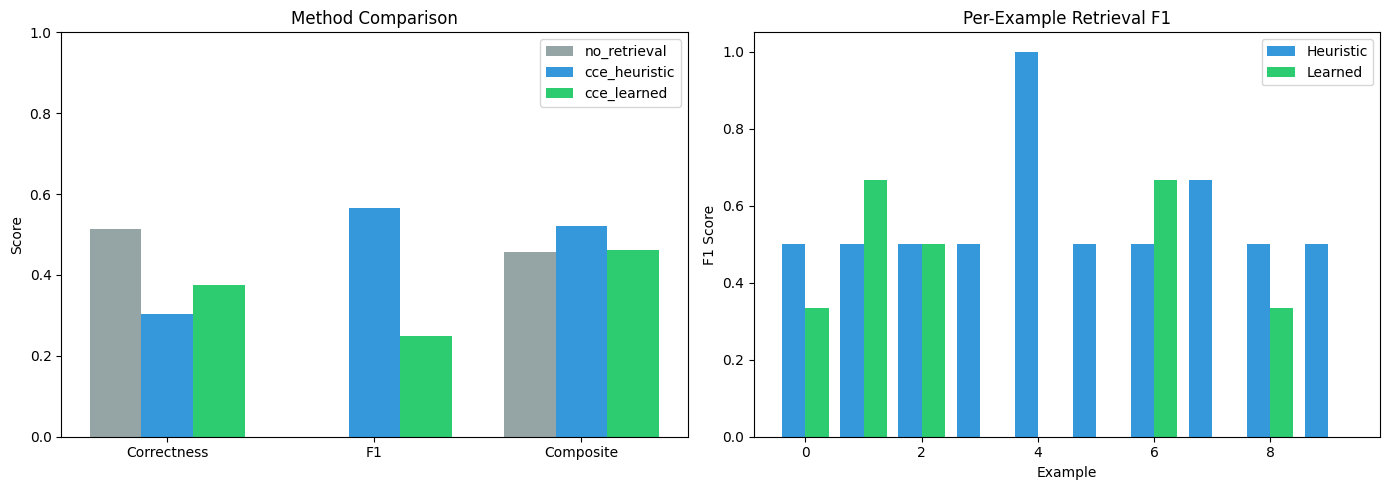

In [21]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
methods = list(agg_results.keys())
metrics = ['Correctness', 'F1', 'Composite']
x = np.arange(len(metrics))
width = 0.25

colors = {'no_retrieval': '#95a5a6', 'cce_heuristic': '#3498db', 'cce_learned': '#2ecc71'}

for i, method in enumerate(methods):
    if agg_results[method]:
        vals = [agg_results[method].get(m, 0) for m in metrics]
        axes[0].bar(x + i * width, vals, width, label=method, color=colors.get(method, '#333'))

axes[0].set_xticks(x + width)
axes[0].set_xticklabels(metrics)
axes[0].set_ylim(0, 1)
axes[0].set_ylabel('Score')
axes[0].set_title('Method Comparison')
axes[0].legend()

# Per-example F1 comparison
if results['cce_learned'] and results['cce_heuristic']:
    learned_f1 = [e['f1'] for e in results['cce_learned']]
    heur_f1 = [e['f1'] for e in results['cce_heuristic']]

    x = np.arange(len(learned_f1))
    axes[1].bar(x - 0.2, heur_f1, 0.4, label='Heuristic', color='#3498db')
    axes[1].bar(x + 0.2, learned_f1, 0.4, label='Learned', color='#2ecc71')
    axes[1].set_xlabel('Example')
    axes[1].set_ylabel('F1 Score')
    axes[1].set_title('Per-Example Retrieval F1')
    axes[1].legend()

plt.tight_layout()
plt.savefig('week9_v3_results.png', dpi=150)
plt.show()

## 15. Save Results

In [22]:
# Save model
torch.save(learned_model.state_dict(), 'learned_query_pooler_v3.pt')
print("Saved: learned_query_pooler_v3.pt")

# Save results
results_summary = {
    'experiment': 'Week9_V3_End_to_End',
    'model': MODEL_NAME,
    'codebase': 'httpx',
    'benchmark_size': len(BENCHMARK),
    'training_samples': len(TRAIN_SAMPLES),
    'aggregated': {k: {m: float(v) for m, v in d.items()} for k, d in agg_results.items()},
}

with open('week9_v3_results.json', 'w') as f:
    json.dump(results_summary, f, indent=2)
print("Saved: week9_v3_results.json")

if IN_COLAB:
    files.download('learned_query_pooler_v3.pt')
    files.download('week9_v3_results.json')
    files.download('week9_v3_results.png')

Saved: learned_query_pooler_v3.pt
Saved: week9_v3_results.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Summary

This notebook provides **end-to-end evaluation** of the Learned Query Pooler:

1. **Real Codebase**: Uses httpx from GitHub
2. **Real LLM**: CodeLlama-7b with 4-bit quantization
3. **CCE Spike Detection**: Triggers retrieval on entropy spikes
4. **Context Injection**: Retrieved code is injected into generation
5. **Full Evaluation**: Correctness, F1, Composite scores

### Methods Compared

| Method | Retrieval Trigger | File Matching |
|--------|------------------|---------------|
| `no_retrieval` | None | None |
| `cce_heuristic` | CCE spike | Keyword matching |
| `cce_learned` | CCE spike | **Learned Query Pooler** |